In [4]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

class SatelliteTX:
    """
    Satellite Transmitter Baseband Processor.

    This class handles the conversion of text data into a baseband
    complex signal ready for RF up-conversion or analog simulation.

    Attributes:
        symbol_rate (int): Number of symbols transmitted per second (Baud rate).
        sps (int): Samples per symbol (Oversampling factor).
        fs (int): System sampling rate in Hz.
        alpha (float): Roll-off factor for the Root Raised Cosine filter.
    """

    def __init__(self, symbol_rate: int = 10000, sps: int = 8, alpha: float = 0.35):
        self.symbol_rate = symbol_rate
        self.sps = sps
        self.fs = symbol_rate * sps
        self.alpha = alpha

    def text_to_bits(self, text: str) -> np.ndarray:
        """
        Convert an ASCII string into a stream of binary bits.
        Each character is represented by 8 bits (MSB first).
        """
        bits = []
        for char in text:
            # Convert char to 8-bit binary string and then to integers
            bits.extend([int(b) for b in format(ord(char), '08b')])
        return np.array(bits)

    def bits_to_qpsk(self, bits: np.ndarray) -> np.ndarray:
        """
        Map a bit stream to complex QPSK symbols.
        Uses Gray coding to minimize bit errors:
        00 -> (1+j), 01 -> (-1+j), 11 -> (-1-j), 10 -> (1-j).
        Symbols are normalized by 1/sqrt(2).
        """
        # Ensure we have an even number of bits for QPSK (2 bits per symbol)
        if len(bits) % 2 != 0:
            bits = np.append(bits, 0)

        # Reshape bit stream into pairs
        reshaped = bits.reshape(-1, 2)
        symbols = []
        for b in reshaped:
            # Mapping logic based on Gray code
            i = 1.0 if b[0] == 0 else -1.0
            q = 1.0 if b[1] == 0 else -1.0
            # Normalize power to 1
            symbols.append(complex(i, q) / np.sqrt(2))
        return np.array(symbols)

    def _generate_rrc_taps(self, num_symbols: int = 10) -> np.ndarray:
        """
        Generate the impulse response (taps) for the Root Raised Cosine filter.
        The filter length is defined by num_symbols in each direction.
        """
        T = 1.0 / self.symbol_rate
        # Time vector centered at 0
        t = np.arange(-num_symbols * T, num_symbols * T + 1/self.fs, 1/self.fs)

        taps = np.zeros(len(t))
        for idx, ti in enumerate(t):
            # Mathematical edge cases for RRC formula
            if ti == 0.0:
                taps[idx] = 1.0 - self.alpha + (4 * self.alpha / np.pi)
            elif abs(ti) == T / (4 * self.alpha):
                taps[idx] = (self.alpha / np.sqrt(2)) * (((1 + 2/np.pi) * np.sin(np.pi/(4 * self.alpha))) + ((1 - 2/np.pi) * np.cos(np.pi/(4 * self.alpha))))
            else:
                # Standard RRC impulse response formula
                num = np.sin(np.pi * ti / T * (1 - self.alpha)) + 4 * self.alpha * ti / T * np.cos(np.pi * ti / T * (1 + self.alpha))
                den = np.pi * ti / T * (1 - (4 * self.alpha * ti / T)**2)
                taps[idx] = num / den
        # Normalize taps to ensure unit energy
        return taps / np.sqrt(np.sum(taps**2))

    def apply_rrc_filter(self, symbols: np.ndarray) -> np.ndarray:
        """
        Perform pulse shaping on the QPSK symbols.
        1. Up-sample the symbols by inserting zeros (L-1 zeros between symbols).
        2. Convolve with the RRC filter taps.
        """
        # Create zero-padded vector (Up-sampling)
        upsampled = np.zeros(len(symbols) * self.sps, dtype=complex)
        upsampled[::self.sps] = symbols

        # Apply finite impulse response (FIR) filter
        taps = self._generate_rrc_taps()
        tx_signal = np.convolve(upsampled, taps, mode='same')
        return tx_signal

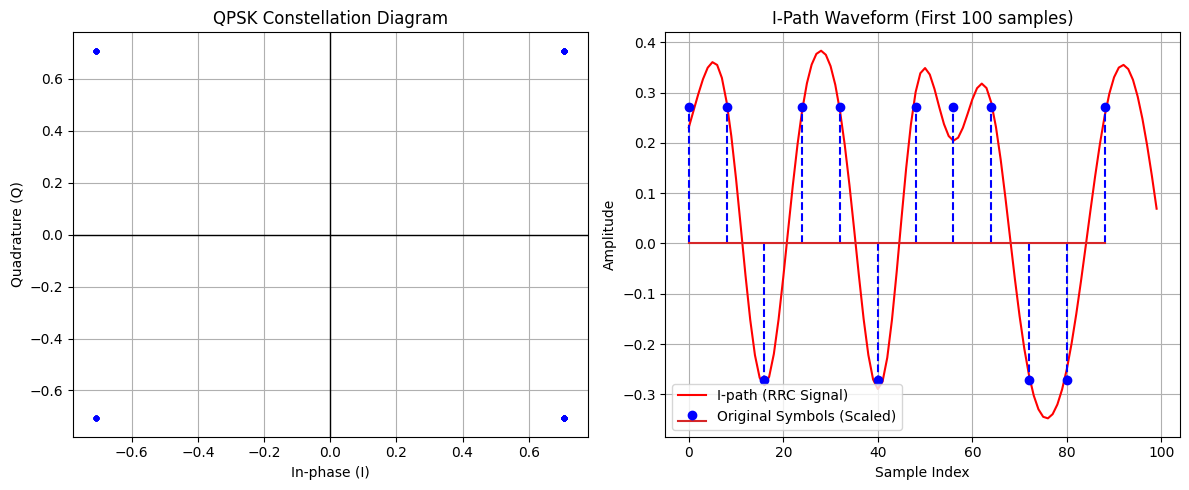

In [3]:
# Unit Test Script - Fixed Visualization Array Slicing
tx = SatelliteTX(symbol_rate=10000, sps=8, alpha=0.35)
test_str = "Hello LEO Satellite!"

# DSP Chain
bits = tx.text_to_bits(test_str)
symbols = tx.bits_to_qpsk(bits)
signal = tx.apply_rrc_filter(symbols)

# Visualization
plt.figure(figsize=(12, 5))

# (A) Constellation Diagram
plt.subplot(1, 2, 1)
plt.scatter(symbols.real, symbols.imag, color='blue', alpha=0.6, s=10)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("QPSK Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)

# (B) RRC Filtered Waveform (In-phase)
plt.subplot(1, 2, 2)
num_samples_to_plot = 100
num_symbols_to_plot = num_samples_to_plot // tx.sps

x_samples = np.arange(num_samples_to_plot)
x_symbols = np.arange(0, num_symbols_to_plot * tx.sps, tx.sps)

plt.plot(x_samples, signal.real[:num_samples_to_plot], 'r-', label='I-path (RRC Signal)')
plt.stem(x_symbols, symbols.real[:num_symbols_to_plot] * np.max(signal.real),
         linefmt='b--', markerfmt='bo', label='Original Symbols (Scaled)')

plt.title("I-Path Waveform (First 100 samples)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()